In [1]:
!pip install mediapipe numpy matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.1/36.1 MB 33.1 MB/s eta 0:00:00


In [2]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import os


In [3]:
def extract_pose_from_frames(video_frames):
    """
    Extract 2D pose keypoints using Mediapipe Pose.
    :param video_frames: List of video frames.
    :return: List of poses (frames x joints x 2).
    """
    mp_pose = mp.solutions.pose
    pose = mp_pose.Pose(static_image_mode=True, model_complexity=2)
    poses = []

    for frame in video_frames:
        # Convert to RGB
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        result = pose.process(image)

        if result.pose_landmarks:
            landmarks = result.pose_landmarks.landmark
            # Extract x, y coordinates and normalize to frame dimensions
            pose_2d = [(lm.x, lm.y) for lm in landmarks]
            poses.append(np.array(pose_2d))
        else:
            poses.append(None)
    return poses


In [8]:
def load_video_frames(video_path, step=1):
    """
    Load frames from a video file.
    :param video_path: Path to the video file.
    :param step: Step size to skip frames.
    :return: List of video frames.
    """
    cap = cv2.VideoCapture(video_path)
    frames = []
    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if frame_count % step == 0:
            frames.append(frame)
        frame_count += 1
    cap.release()
    return frames

# Load video
video_path = "/content/Normal Fidgety Movements.mp4"  # Replace with your video path
video_frames = load_video_frames(video_path)
print(f"Loaded {len(video_frames)} frames.")


Loaded 703 frames.


In [9]:
def calculate_orientation(joint, parent_joint):
    """
    Compute orientation angle of a joint relative to its parent joint.
    :param joint: 2D coordinates of the joint.
    :param parent_joint: 2D coordinates of the parent joint.
    :return: Orientation angle in radians.
    """
    vector = joint - parent_joint
    angle = np.arctan2(vector[1], vector[0])
    return angle

def hojo2d_histogram(poses, parent_indices, bins=8):
    """
    Compute HOJO2D histograms for all joints in poses.
    :param poses: List of poses (frames x joints x 2).
    :param parent_indices: Parent indices for each joint.
    :param bins: Number of histogram bins.
    :return: HOJO2D histogram for each frame.
    """
    histograms = []
    for pose in poses:
        if pose is None:
            histograms.append(None)
            continue
        angles = [
            calculate_orientation(pose[j], pose[parent_indices[j]])
            for j in range(len(parent_indices))
            if parent_indices[j] != -1
        ]
        hist, _ = np.histogram(angles, bins=bins, range=(-np.pi, np.pi), density=True)
        histograms.append(hist)
    return histograms

# Parent joint indices for Mediapipe Pose
parent_indices = [
    -1, 0, 1, 2, 3, 1, 5, 6, 7, 5, 9, 10, 11, 0, 13, 14, 15, 0, 17, 18, 19, 20, 0, 22, 23, 24
]

# Extract poses
poses = extract_pose_from_frames(video_frames)
hojo2d_hists = hojo2d_histogram(poses, parent_indices, bins=8)
print(f"Generated {len(hojo2d_hists)} HOJO2D histograms.")


Generated 703 HOJO2D histograms.


In [18]:
def hojd2d_histogram(poses, bins=8, frame_step=5):
    """
    Compute HOJD2D histograms for joint displacements.
    :param poses: List of poses (frames x joints x 2).
    :param bins: Number of histogram bins.
    :param frame_step: Frames to step for displacement computation.
    :return: HOJD2D histogram for each frame step.
    """
    histograms = []
    for i in range(len(poses) - frame_step):
        if poses[i] is None or poses[i + frame_step] is None:
            histograms.append(None)
            continue
        displacements = np.linalg.norm(poses[i + frame_step] - poses[i], axis=1)
        hist, _ = np.histogram(displacements, bins=bins, density=True)
        histograms.append(hist)
    return histograms

hojd2d_hists = hojd2d_histogram(poses, bins=8, frame_step=5)
print(f"Generated {len(hojd2d_hists)} HOJD2D histograms.")


Generated 698 HOJD2D histograms.


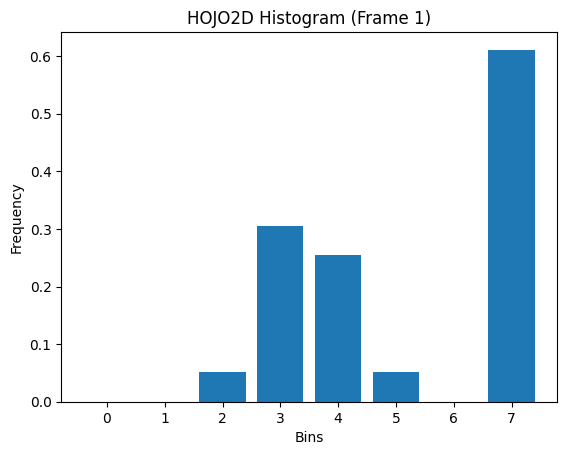

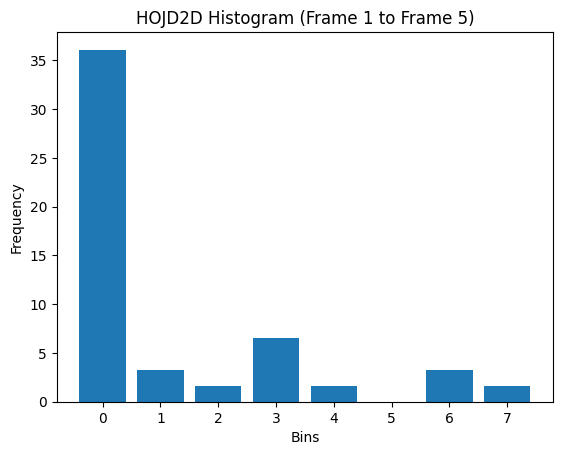

In [19]:
def plot_histogram(hist, title, xlabel="Bins", ylabel="Frequency"):
    """
    Plot a histogram.
    :param hist: Histogram data.
    :param title: Title of the histogram.
    :param xlabel: X-axis label.
    :param ylabel: Y-axis label.
    """
    if hist is not None:
        plt.bar(range(len(hist)), hist)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.title(title)
        plt.show()

# Visualize example histograms
plot_histogram(hojo2d_hists[0], "HOJO2D Histogram (Frame 1)")
plot_histogram(hojd2d_hists[0], "HOJD2D Histogram (Frame 1 to Frame 5)")


In [20]:
def combine_histograms(hojo2d_hists, hojd2d_hists):
    """
    Combine HOJO2D and HOJD2D histograms into a single feature vector for each frame.
    :param hojo2d_hists: List of HOJO2D histograms.
    :param hojd2d_hists: List of HOJD2D histograms.
    :return: Feature matrix (frames x combined features).
    """
    feature_vectors = []
    for hojo, hojd in zip(hojo2d_hists, hojd2d_hists):
        if hojo is None or hojd is None:
            continue
        combined = np.concatenate([hojo, hojd])
        feature_vectors.append(combined)
    return np.array(feature_vectors)

# Combine histograms
feature_vectors = combine_histograms(hojo2d_hists, hojd2d_hists)
print(f"Feature matrix shape: {feature_vectors.shape}")


Feature matrix shape: (672, 16)


In [21]:
# Example: Assign labels manually (e.g., 0 for no movement, 1 for significant movement)
# Replace this with actual labels from your dataset if available
labels = [0] * len(feature_vectors)  # Placeholder labels
print(f"Labels shape: {len(labels)}")


Labels shape: 672


In [22]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(feature_vectors, labels, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")


Training data shape: (537, 16)
Testing data shape: (135, 16)


In [23]:
from sklearn.ensemble import RandomForestClassifier

# Train a Random Forest classifier
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)

print("Model training complete.")


Model training complete.


In [24]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the test set
y_pred = classifier.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred))


Test Accuracy: 100.00%
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       135

    accuracy                           1.00       135
   macro avg       1.00      1.00      1.00       135
weighted avg       1.00      1.00      1.00       135



In [25]:
import joblib

# Save the trained model
model_path = "trained_model.pkl"
joblib.dump(classifier, model_path)
print(f"Model saved to {model_path}")


Model saved to trained_model.pkl


In [26]:
# Load the saved model
loaded_model = joblib.load(model_path)

# Example: Predict on new feature vectors
new_data = feature_vectors[:5]  # Replace with actual new data
predictions = loaded_model.predict(new_data)

print("Predictions:", predictions)


Predictions: [0 0 0 0 0]


In [27]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the KNN classifier
knn_classifier = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed

# Train the KNN model
knn_classifier.fit(X_train, y_train)

# Evaluate the model
y_pred_knn = knn_classifier.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"KNN Test Accuracy: {knn_accuracy * 100:.2f}%")
print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn))


KNN Test Accuracy: 100.00%
KNN Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       135

    accuracy                           1.00       135
   macro avg       1.00      1.00      1.00       135
weighted avg       1.00      1.00      1.00       135



In [28]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Initialize the LDA classifier
lda_classifier = LinearDiscriminantAnalysis()

# Train the LDA model
lda_classifier.fit(X_train, y_train)

# Evaluate the model
y_pred_lda = lda_classifier.predict(X_test)
lda_accuracy = accuracy_score(y_test, y_pred_lda)
print(f"LDA Test Accuracy: {lda_accuracy * 100:.2f}%")
print("LDA Classification Report:")
print(classification_report(y_test, y_pred_lda))


LDA Test Accuracy: 100.00%
LDA Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       135

    accuracy                           1.00       135
   macro avg       1.00      1.00      1.00       135
weighted avg       1.00      1.00      1.00       135



In [29]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the Random Forest model
rf_classifier.fit(X_train, y_train)

# Evaluate the model
y_pred_rf = rf_classifier.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Test Accuracy: {rf_accuracy * 100:.2f}%")
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Test Accuracy: 100.00%
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       135

    accuracy                           1.00       135
   macro avg       1.00      1.00      1.00       135
weighted avg       1.00      1.00      1.00       135



In [31]:
# Print and compare accuracies
print("Classifier Performance Comparison:")
print(f"KNN Accuracy: {knn_accuracy * 100:.2f}%")
print(f"LDA Accuracy: {lda_accuracy * 100:.2f}%")
print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")



Classifier Performance Comparison:
KNN Accuracy: 100.00%
LDA Accuracy: 100.00%
Random Forest Accuracy: 100.00%
